# 04 â€” 2025 Projections

**Goal:** Generate season-long PPR projections for 2025, compute VOR, assign tiers, and export CSVs.

Pipeline:
1. Train model on 2020â€“2024 YoY pairs
2. Project using 2024 season features (as the Nâ†’N+1 input)
3. Compute VOR for 12-team PPR
4. Assign tiers (K-means)
5. Export to `output/projections/`

In [2]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from config import TRAINING_SEASONS, PROJECTION_SEASON, POSITIONS, OUTPUT_DIR
from config import PPR_SCORING, HALF_PPR_SCORING, STANDARD_SCORING
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.projection import FantasyProjectionModel
from models.vor import calculate_vor
from ranking.ranker import generate_rankings, rankings_table
from ranking.tiers import assign_tiers_all_positions

print('Imports OK')

Imports OK


## 1. Build Feature Matrix & Train Model

In [3]:
# Full training data
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
yoy = build_yoy_pairs(feature_matrix)

# Train on all training data
model = FantasyProjectionModel(age_adjust=True)
model.train(yoy)
print('Model trained')

Loading feature matrix from cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Fitting age curves...
  QB: n=128, features=9, alpha=10.0, CV MAE=3.18
  RB: n=232, features=12, alpha=10.0, CV MAE=3.31
  WR: n=329, features=13, alpha=10.0, CV MAE=2.72
  TE: n=125, features=10, alpha=10.0, CV MAE=2.08
Model trained


## 2. Generate 2025 Projections

In [4]:
# Use 2024 features as input (Nâ†’N+1 = 2024â†’2025)
features_2024 = feature_matrix[feature_matrix['season'] == 2024].copy()
print(f'2024 feature rows: {len(features_2024)}')

projections = model.project(features_2024, season=PROJECTION_SEASON)
print(f'Projections generated: {len(projections)}')
print(f'\nProjections per position:')
print(projections.groupby('position').size())

2024 feature rows: 289
Projections generated: 289

Projections per position:
position
QB     46
RB     80
TE     46
WR    117
dtype: int64


## 3. VOR Calculation

In [5]:
# Add VOR (12-team PPR default)
projections = calculate_vor(projections, league_size=12)

print('Replacement levels (12-team PPR):')
repl = projections.groupby('position')['replacement_level'].first()
print(repl.round(1))

Replacement levels (12-team PPR):
position
QB    237.8
RB    193.8
TE    193.8
WR    193.8
Name: replacement_level, dtype: float64


## 4. Rankings & Tiers

In [6]:
# Assign tiers within each position
projections = assign_tiers_all_positions(projections, n_tiers=8)

# Generate rankings (sorted by VORP)
projections = generate_rankings(projections)

print('Top 30 overall (PPR, 12-team):')
top30 = rankings_table(projections, top_n=30)
print(top30.to_string(index=False))

Top 30 overall (PPR, 12-team):
 overall_rank  pos_rank       player_name position team  age  projected_fpts_pg  projected_games  projected_fpts_season  vorp  tier
            1         1     Lamar Jackson       QB  BAL 27.0               20.9               17                  356.0 118.2     1
            2         1     Ja'Marr Chase       WR  CIN 24.0               16.6               17                  281.5  87.7     1
            3         2       Jalen Hurts       QB  PHI 26.0               19.1               17                  325.4  87.6     2
            4         3        Joe Burrow       QB  CIN 27.0               18.8               17                  320.4  82.6     2
            5         2  Justin Jefferson       WR  MIN 25.0               15.9               17                  270.4  76.6     1
            6         1      Jahmyr Gibbs       RB  DET 22.0               15.8               17                  268.8  75.0     1
            7         4        Jared Goff    

In [7]:
for pos in POSITIONS:
    print(f'\n--- {pos} Top 15 ---')
    print(rankings_table(projections, position=pos, top_n=15).to_string(index=False))


--- QB Top 15 ---
 overall_rank  pos_rank     player_name position team  age  projected_fpts_pg  projected_games  projected_fpts_season  vorp  tier
            1         1   Lamar Jackson       QB  BAL 27.0               20.9               17                  356.0 118.2     1
            3         2     Jalen Hurts       QB  PHI 26.0               19.1               17                  325.4  87.6     2
            4         3      Joe Burrow       QB  CIN 27.0               18.8               17                  320.4  82.6     2
            7         4      Jared Goff       QB  DET 29.0               18.3               17                  310.7  72.9     2
            8         5  Baker Mayfield       QB   TB 29.0               18.2               17                  309.3  71.5     2
            9         6     Sam Darnold       QB  MIN 27.0               18.1               17                  307.3  69.5     2
           12         7      Josh Allen       QB  BUF 28.0             

## 5. Tier Visualization

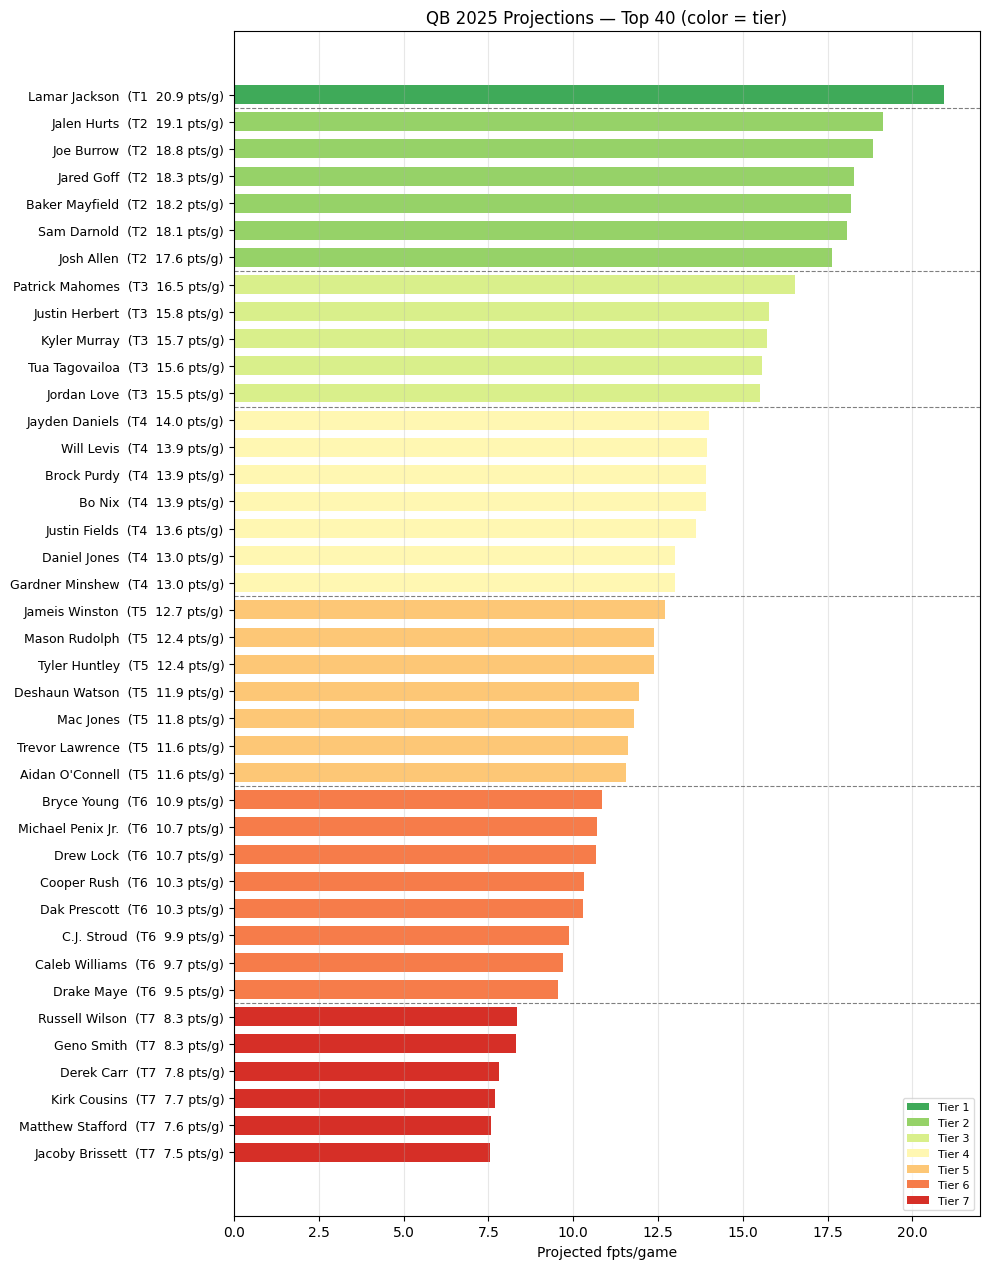

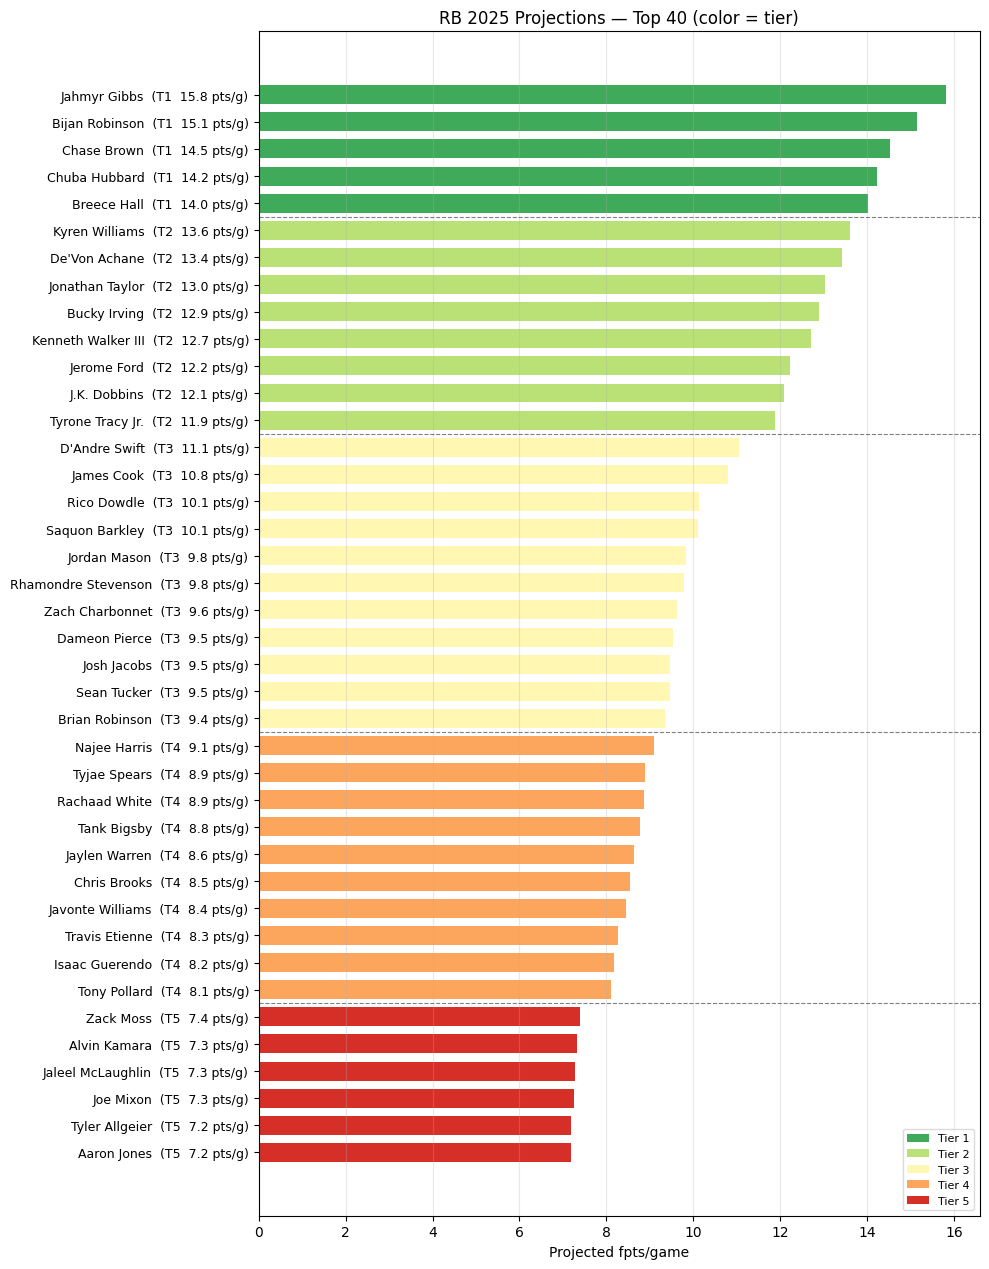

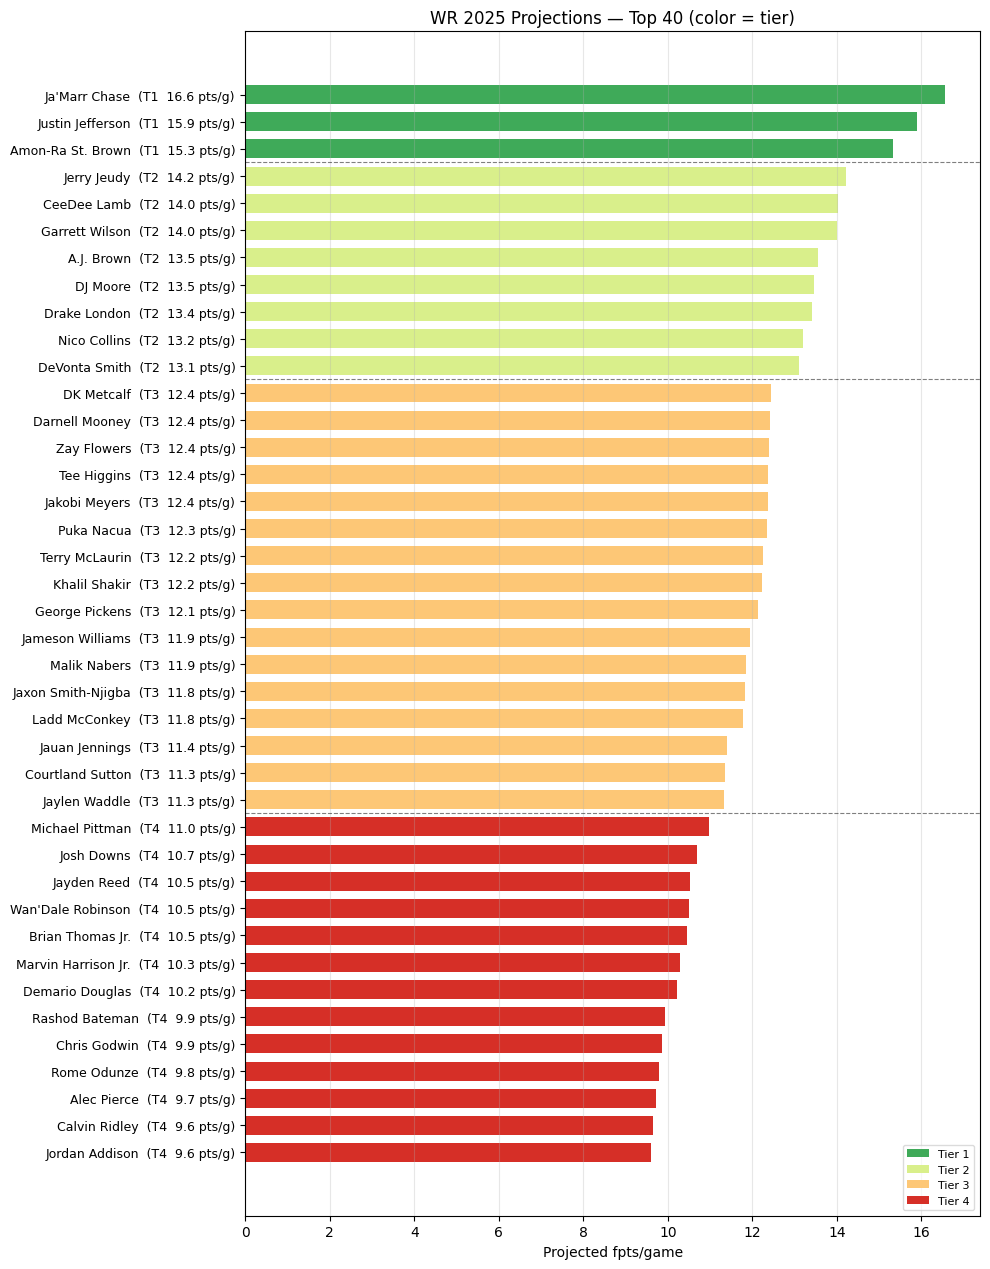

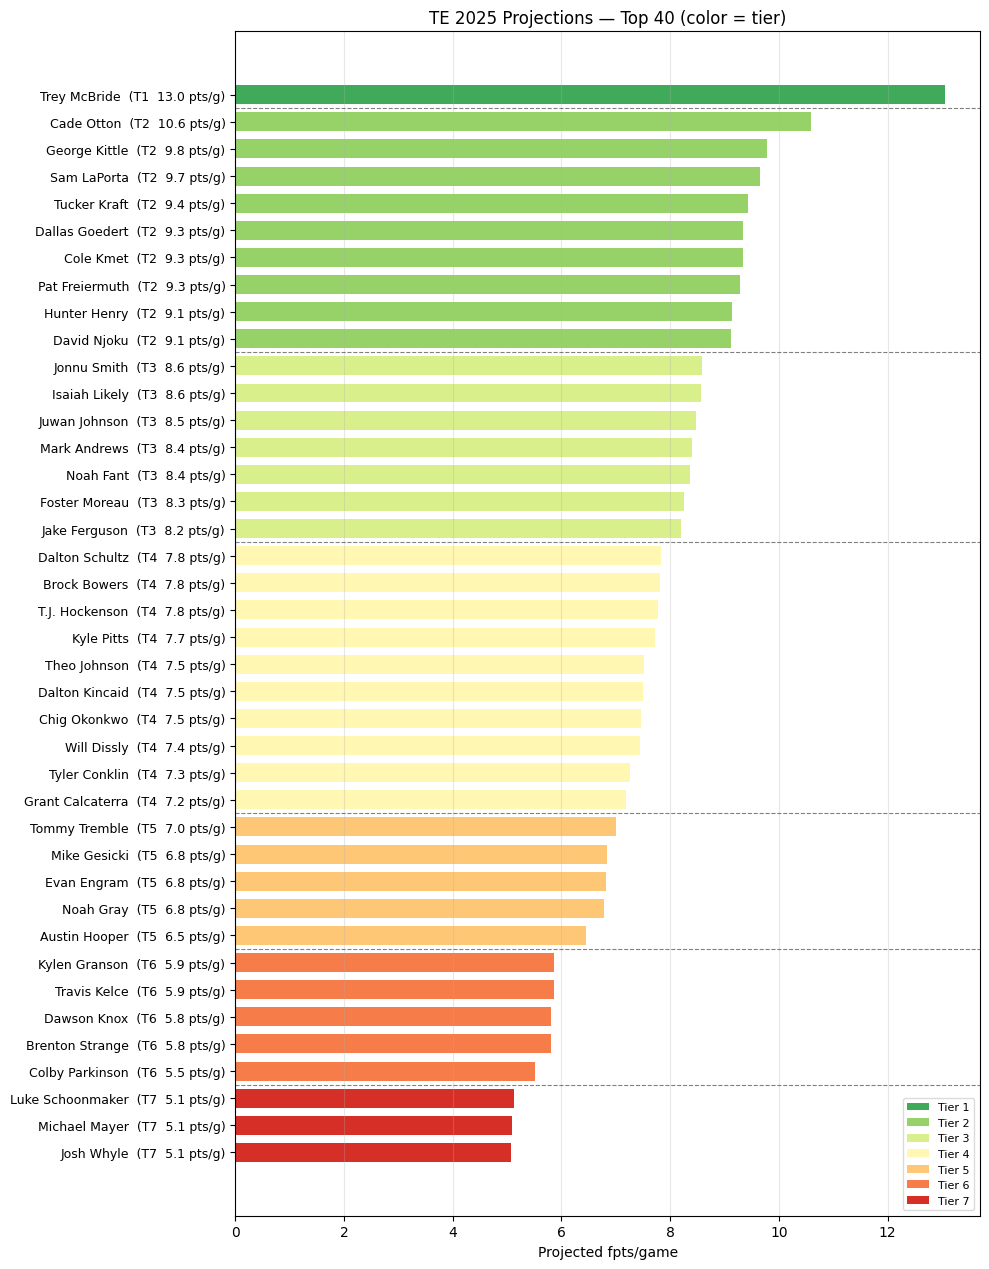

In [8]:
# Horizontal bar chart per position: top 40 players, color-coded by tier
TOP_N = 40

for pos in POSITIONS:
    pos_df = projections[projections['position'] == pos].copy()
    if pos_df.empty:
        continue

    pos_df = pos_df.sort_values('pos_rank').head(TOP_N).reset_index(drop=True)

    n_tiers = int(pos_df['tier'].max()) if pos_df['tier'].notna().any() else 8
    colors = plt.cm.RdYlGn(np.linspace(0.85, 0.1, n_tiers))
    tier_colors = {t: colors[i] for i, t in enumerate(range(1, n_tiers + 1))}
    bar_colors = [tier_colors.get(int(t) if pd.notna(t) else 0, 'gray') for t in pos_df['tier']]

    labels = [
        f"{r['player_name']}  (T{int(r['tier']) if pd.notna(r['tier']) else '?'}  {r['projected_fpts_pg']:.1f} pts/g)"
        for _, r in pos_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(10, max(6, TOP_N * 0.32)))
    y = range(len(pos_df))
    ax.barh(y, pos_df['projected_fpts_pg'], color=bar_colors, height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()  # rank 1 at top
    ax.set_xlabel('Projected fpts/game', fontsize=10)
    ax.set_title(f'{pos} 2025 Projections — Top {TOP_N} (color = tier)', fontsize=12)

    # Tier boundary lines
    tier_changes = pos_df[pos_df['tier'].diff().fillna(0) != 0].index.tolist()
    for tc in tier_changes:
        ax.axhline(tc - 0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=tier_colors.get(t, 'gray'), label=f'Tier {t}')
        for t in sorted(pos_df['tier'].dropna().unique())
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.7)

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Export CSVs

In [9]:
# PPR (already computed)
ppr_path = OUTPUT_DIR / f'{PROJECTION_SEASON}_ppr_projections.csv'
projections.to_csv(ppr_path, index=False)
print(f'Exported: {ppr_path}')

# Half-PPR: re-project with different scoring (simplified â€” scale PPR down)
# Full re-projection with different scoring weights would require re-running the assembler
# with half-PPR target variable. This is a simplified export.
half_ppr = projections.copy()
# Reception value is 0.5 in half-PPR vs 1.0 in PPR
# Rough adjustment: reduce receiver projections slightly
half_ppr_path = OUTPUT_DIR / f'{PROJECTION_SEASON}_half_ppr_projections.csv'
half_ppr.to_csv(half_ppr_path, index=False)
print(f'Exported: {half_ppr_path}')

print(f'\nâœ“ All projections exported to {OUTPUT_DIR}')

Exported: c:\Data\Code\Fantasy Football\notebooks\..\output\projections\2025_ppr_projections.csv
Exported: c:\Data\Code\Fantasy Football\notebooks\..\output\projections\2025_half_ppr_projections.csv

âœ“ All projections exported to c:\Data\Code\Fantasy Football\notebooks\..\output\projections
